<a href="https://colab.research.google.com/github/Sergiodzm99/Proyect-Model_MLB/blob/main/Modelo_con_Odds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='00FF00'> EDA e Ingenieria de Fetures



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### <font color='00FFFF'> DF con Datos Aletarnativos y Tradicional
EL archivo se generó utilizando de los siguientes codigos:
* [df_model_experiment](https://colab.research.google.com/drive/1dUlxqtReswmMc8C5xWjd8jT8BkOVxXN5#scrollTo=QE4sYPkaMiwR)


In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/1. Cursos/1. UNIR/Master IA/4to Semestre/Proyecto Final/Base de Datos/Odds/df_model_experiment.parquet')

In [ ]:
df = (df.dropna().copy())

In [ ]:
print("Shape:", df.shape)
print("Número de columnas:", df.shape[1])
print("Partidos únicos:", df["game_pk"].nunique())

Shape: (5312, 103)
Número de columnas: 103
Partidos únicos: 5237


In [ ]:
print("Temporadas:")
print(df["season"].value_counts().sort_index())

print("\nRango de fechas:")
print("Fecha mínima:", df["official_date"].min())
print("Fecha máxima:", df["official_date"].max())

Temporadas:
season
2023    1011
2024    2437
2025    1864
Name: count, dtype: int64

Rango de fechas:
Fecha mínima: 2023-07-19 00:00:00
Fecha máxima: 2025-08-16 00:00:00


### <font color='00FFFF'> Distribucion


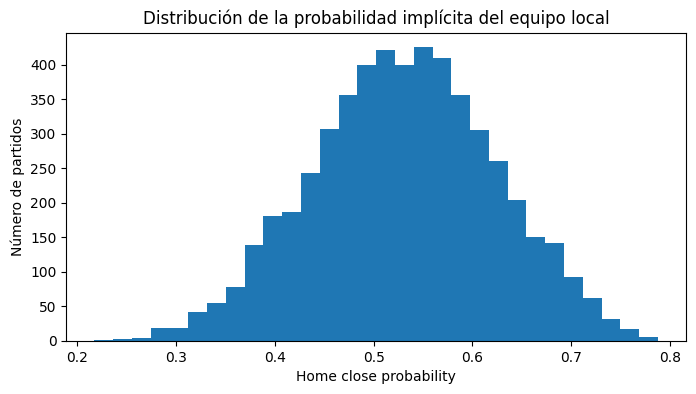

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(
    df["home_close_prob_mean"],
    bins=30
)

plt.xlabel("Home close probability")
plt.ylabel("Número de partidos")
plt.title("Distribución de la probabilidad implícita del equipo local")

plt.show()

In [ ]:
df["home_close_prob_mean"].describe()

,home_close_prob_mean
count,5312.000000
mean,0.530528
std,0.092682
min,0.217071
25%,0.467514
50%,0.532050
75%,0.595007
max,0.788070


In [ ]:
bins = [0,0.40,0.45,0.50,0.55,0.60,0.70,1]

(
    pd.cut(
        df["home_close_prob_mean"],
        bins=bins
    )
    .value_counts()
    .sort_index()
)

,count
home_close_prob_mean,
"(0.0, 0.4]",457
"(0.4, 0.45]",583
"(0.45, 0.5]",929
"(0.5, 0.55]",1079
"(0.55, 0.6]",1024
"(0.6, 0.7]",1062
"(0.7, 1.0]",178


In [ ]:
(
    (df["home_close_prob_mean"] > 0.5)
    .mean()
)

np.float64(0.6293298192771084)

In [ ]:
cal = (
    df.assign(
        prob_bin=pd.cut(
            df["home_close_prob_mean"],
            bins=np.arange(0.20, 0.85, 0.05)
        )
    )
    .groupby("prob_bin", observed=False)
    .agg(
        market_prob=("home_close_prob_mean", "mean"),
        actual_win_rate=("home_win", "mean"),
        games=("home_win", "size")
    )
    .reset_index()
)

cal

,prob_bin,market_prob,actual_win_rate,games
0,"(0.2, 0.25]",0.229928,0.000000,2
1,"(0.25, 0.3]",0.282240,0.296296,27
2,"(0.3, 0.35]",0.329205,0.288288,111
3,"(0.35, 0.4]",0.379355,0.378549,317
4,"(0.4, 0.45]",0.426890,0.451115,583
5,"(0.45, 0.5]",0.476353,0.476293,928
6,"(0.5, 0.55]",0.524816,0.524074,1080
7,"(0.55, 0.6]",0.573205,0.542969,1024
8,"(0.6, 0.65]",0.622545,0.601439,695
9,"(0.65, 0.7]",0.673128,0.678474,367


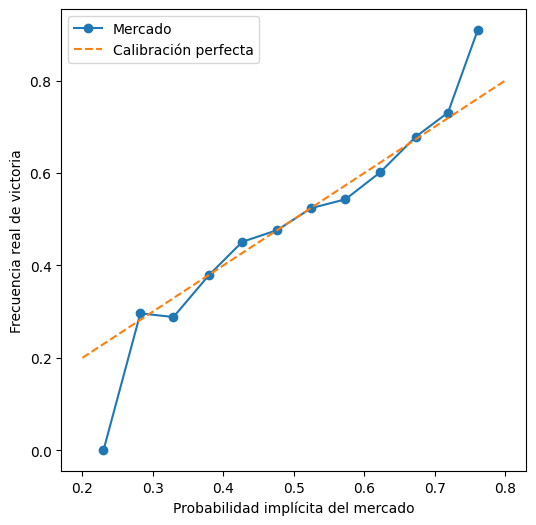

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(
    cal["market_prob"],
    cal["actual_win_rate"],
    marker="o",
    label="Mercado"
)

plt.plot(
    [0.2,0.8],
    [0.2,0.8],
    "--",
    label="Calibración perfecta"
)

plt.xlabel("Probabilidad implícita del mercado")
plt.ylabel("Frecuencia real de victoria")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    df["home_win"],
    df["home_close_prob_mean"]
)

np.float64(0.5979575273926973)

### <font color='00FFFF'> EDA


In [ ]:
market_features = [
    "home_close_prob_mean",
    "home_open_prob_mean",
    "close_market_strength",
    "open_market_strength",
    "home_line_movement",
    "away_line_movement",
    "num_sportsbooks",
]

In [ ]:
corr = df[market_features].corr()

corr.round(3)

,home_close_prob_mean,home_open_prob_mean,close_market_strength,open_market_strength,home_line_movement,away_line_movement,num_sportsbooks
home_close_prob_mean,1.000,0.950,0.394,0.352,0.300,-0.300,-0.010
home_open_prob_mean,0.950,1.000,0.379,0.377,-0.013,0.013,-0.009
close_market_strength,0.394,0.379,1.000,0.897,0.102,-0.102,-0.001
open_market_strength,0.352,0.377,0.897,1.000,-0.023,0.023,-0.004
home_line_movement,0.300,-0.013,0.102,-0.023,1.000,-1.000,-0.002
away_line_movement,-0.300,0.013,-0.102,0.023,-1.000,1.000,0.002
num_sportsbooks,-0.010,-0.009,-0.001,-0.004,-0.002,0.002,1.000


In [ ]:
df[
    market_features + ["home_win"]
].corr()["home_win"].sort_values()

,home_win
away_line_movement,-0.063472
num_sportsbooks,0.000957
home_line_movement,0.063472
open_market_strength,0.072024
close_market_strength,0.074815
home_open_prob_mean,0.165623
home_close_prob_mean,0.177861
home_win,1.000000


In [ ]:
market_features = [

    "home_close_prob_mean",

    "close_market_strength",

    "home_line_movement"

]

# <font color='00FF00'> Entrenamiento de Modelos



### <font color='00FFFF'> Conjuntos de Variables


In [ ]:
target = "home_win"

base_numeric_features = [
    # Contexto del partido
    "seriesGameNumber",

    # Rendimiento histórico
    "win_pct_diff",
    "wins_diff",

    # Baseball Savant
    "xwoba_diff",
    "xba_diff",
    "launch_speed_diff",
    "iso_diff"
]

base_categorical_features = [
    "dayNight",
    "teams.home.team.name",
    "teams.away.team.name"
]

market_feature_groups = {
    "consensus": [
        "home_close_prob_mean"
    ],

    "confidence": [
        "close_market_strength"
    ],

    "movement": [
        "home_line_movement"
    ]
}


## <font color='00FFFF'> Configuración de Experimentos


In [ ]:
experiment_configs = {

    "E1_Base": {
        "description": "Stats API + Baseball Savant",
        "added_feature": "Ninguna",
        "numeric_features": base_numeric_features.copy(),
        "categorical_features": base_categorical_features.copy()
    },

    "E2_Consensus": {
        "description": "Modelo base + consenso de cierre del mercado",
        "added_feature": "home_close_prob_mean",
        "numeric_features": (
            base_numeric_features
            + market_feature_groups["consensus"]
        ),
        "categorical_features": base_categorical_features.copy()
    },

    "E3_Confidence": {
        "description": (
            "Modelo base + consenso de cierre "
            "+ fortaleza del mercado"
        ),
        "added_feature": "close_market_strength",
        "numeric_features": (
            base_numeric_features
            + market_feature_groups["consensus"]
            + market_feature_groups["confidence"]
        ),
        "categorical_features": base_categorical_features.copy()
    },

    "E4_Movement": {
        "description": (
            "Modelo base + consenso de cierre "
            "+ fortaleza del mercado "
            "+ movimiento de línea"
        ),
        "added_feature": "home_line_movement",
        "numeric_features": (
            base_numeric_features
            + market_feature_groups["consensus"]
            + market_feature_groups["confidence"]
            + market_feature_groups["movement"]
        ),
        "categorical_features": base_categorical_features.copy()
    }
}

### <font color='00FFFF'> Validacion Variables

In [ ]:
for experiment_name, config in experiment_configs.items():
    print("=" * 70)
    print(experiment_name)
    print(config["description"])
    print("\nVariables numéricas:")
    print(config["numeric_features"])
    print("\nVariables categóricas:")
    print(config["categorical_features"])

E1_Base
Stats API + Baseball Savant

Variables numéricas:
['seriesGameNumber', 'win_pct_diff', 'wins_diff', 'xwoba_diff', 'xba_diff', 'launch_speed_diff', 'iso_diff']

Variables categóricas:
['dayNight', 'teams.home.team.name', 'teams.away.team.name']
E2_Consensus
Modelo base + consenso de cierre del mercado

Variables numéricas:
['seriesGameNumber', 'win_pct_diff', 'wins_diff', 'xwoba_diff', 'xba_diff', 'launch_speed_diff', 'iso_diff', 'home_close_prob_mean']

Variables categóricas:
['dayNight', 'teams.home.team.name', 'teams.away.team.name']
E3_Confidence
Modelo base + consenso de cierre + fortaleza del mercado

Variables numéricas:
['seriesGameNumber', 'win_pct_diff', 'wins_diff', 'xwoba_diff', 'xba_diff', 'launch_speed_diff', 'iso_diff', 'home_close_prob_mean', 'close_market_strength']

Variables categóricas:
['dayNight', 'teams.home.team.name', 'teams.away.team.name']
E4_Movement
Modelo base + consenso de cierre + fortaleza del mercado + movimiento de línea

Variables numéricas:
[

In [ ]:
required_features = {target}

for config in experiment_configs.values():
    required_features.update(config["numeric_features"])
    required_features.update(config["categorical_features"])

missing_features = sorted(
    required_features - set(df.columns)
)

print("Variables faltantes:", missing_features)

Variables faltantes: []


### <font color='00FFFF'> Partición Train / Test

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=df[target]
)

print("Train:", len(train_idx))
print("Test :", len(test_idx))

print("Proporción home_win train:", df.loc[train_idx, target].mean())
print("Proporción home_win test :", df.loc[test_idx, target].mean())

Train: 4249
Test : 1063
Proporción home_win train: 0.5248293716168511
Proporción home_win test : 0.5249294449670743


### <font color='00FFFF'> Función de Preprocesamiento y Entrenamiento


In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def run_experiment(
    df,
    experiment_name,
    description,
    numeric_features,
    categorical_features,
    target,
    train_idx,
    test_idx,
    estimator
):
    """
    Entrena y evalúa un modelo de clasificación usando una partición fija.

    Parámetros
    ----------
    estimator:
        Modelo compatible con scikit-learn y con predict_proba.
    """

    selected_features = numeric_features + categorical_features

    X = df[selected_features].copy()
    y = df[target].copy()

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]

    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_features
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            )
        ]
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(estimator))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "experiment": experiment_name,
        "description": description,
        "model": estimator.__class__.__name__,
        "n_numeric_features": len(numeric_features),
        "n_categorical_features": len(categorical_features),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    return {
        "metrics": metrics,
        "pipeline": pipeline,
        "y_test": y_test.copy(),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "features": selected_features.copy()
    }

### <font color='00FFFF'> Definición del Modelo


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

estimators = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
all_experiment_results = {}

for model_name, estimator in estimators.items():

    for experiment_name, config in experiment_configs.items():

        result = run_experiment(
            df=df,
            experiment_name=experiment_name,
            description=config["description"],
            numeric_features=config["numeric_features"],
            categorical_features=config["categorical_features"],
            target=target,
            train_idx=train_idx,
            test_idx=test_idx,
            estimator=estimator
        )

        result["metrics"]["model_name"] = model_name
        result["metrics"]["added_feature"] = config["added_feature"]

        result_key = f"{model_name}_{experiment_name}"
        all_experiment_results[result_key] = result

        print(
            f"{model_name:<20}"
            f" | {experiment_name:<16}"
            f" | Accuracy = {result['metrics']['accuracy']:.4f}"
            f" | ROC-AUC = {result['metrics']['roc_auc']:.4f}"
        )

LogisticRegression   | E1_Base          | Accuracy = 0.5466 | ROC-AUC = 0.5631
LogisticRegression   | E2_Consensus     | Accuracy = 0.5691 | ROC-AUC = 0.5796
LogisticRegression   | E3_Confidence    | Accuracy = 0.5691 | ROC-AUC = 0.5799
LogisticRegression   | E4_Movement      | Accuracy = 0.5560 | ROC-AUC = 0.5773
RandomForest         | E1_Base          | Accuracy = 0.5240 | ROC-AUC = 0.5296
RandomForest         | E2_Consensus     | Accuracy = 0.5343 | ROC-AUC = 0.5402
RandomForest         | E3_Confidence    | Accuracy = 0.5400 | ROC-AUC = 0.5451
RandomForest         | E4_Movement      | Accuracy = 0.5343 | ROC-AUC = 0.5487
XGBoost              | E1_Base          | Accuracy = 0.5381 | ROC-AUC = 0.5476
XGBoost              | E2_Consensus     | Accuracy = 0.5372 | ROC-AUC = 0.5526
XGBoost              | E3_Confidence    | Accuracy = 0.5428 | ROC-AUC = 0.5516
XGBoost              | E4_Movement      | Accuracy = 0.5212 | ROC-AUC = 0.5480


In [ ]:
results_df = pd.DataFrame(
    [
        result["metrics"]
        for result in all_experiment_results.values()
    ]
)

results_df = results_df[
    [
        "model_name",
        "experiment",
        "description",
        "added_feature",
        "n_numeric_features",
        "n_categorical_features",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
]

results_df = results_df.sort_values(
    by=["model_name", "experiment"]
).reset_index(drop=True)

display(results_df)

,model_name,experiment,description,added_feature,n_numeric_features,n_categorical_features,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,E1_Base,Stats API + Baseball Savant,Ninguna,7,3,0.546566,0.561688,0.620072,0.589438,0.563086
1,LogisticRegression,E2_Consensus,Modelo base + consenso de cierre del mercado,home_close_prob_mean,8,3,0.569144,0.580645,0.645161,0.611205,0.579588
2,LogisticRegression,E3_Confidence,Modelo base + consenso de cierre + fortaleza d...,close_market_strength,9,3,0.569144,0.580645,0.645161,0.611205,0.579886
3,LogisticRegression,E4_Movement,Modelo base + consenso de cierre + fortaleza d...,home_line_movement,10,3,0.555974,0.571192,0.618280,0.593804,0.577320
4,RandomForest,E1_Base,Stats API + Baseball Savant,Ninguna,7,3,0.523989,0.543478,0.582437,0.562284,0.529612
5,RandomForest,E2_Consensus,Modelo base + consenso de cierre del mercado,home_close_prob_mean,8,3,0.534337,0.553480,0.584229,0.568439,0.540175
6,RandomForest,E3_Confidence,Modelo base + consenso de cierre + fortaleza d...,close_market_strength,9,3,0.539981,0.559177,0.584229,0.571429,0.545133
7,RandomForest,E4_Movement,Modelo base + consenso de cierre + fortaleza d...,home_line_movement,10,3,0.534337,0.554974,0.569892,0.562334,0.548728
8,XGBoost,E1_Base,Stats API + Baseball Savant,Ninguna,7,3,0.538100,0.553772,0.618280,0.584251,0.547564
9,XGBoost,E2_Consensus,Modelo base + consenso de cierre del mercado,home_close_prob_mean,8,3,0.537159,0.557093,0.577061,0.566901,0.552596


In [ ]:
results_df["delta_accuracy_vs_base"] = (
    results_df["accuracy"]
    - results_df.groupby("model_name")["accuracy"].transform("first")
)

results_df["delta_roc_auc_vs_base"] = (
    results_df["roc_auc"]
    - results_df.groupby("model_name")["roc_auc"].transform("first")
)

results_df["delta_accuracy_previous"] = (
    results_df.groupby("model_name")["accuracy"].diff()
)

results_df["delta_roc_auc_previous"] = (
    results_df.groupby("model_name")["roc_auc"].diff()
)

In [ ]:
display(
    results_df[
        [
            "model_name",
            "experiment",
            "added_feature",
            "accuracy",
            "delta_accuracy_vs_base",
            "delta_accuracy_previous",
            "roc_auc",
            "delta_roc_auc_vs_base",
            "delta_roc_auc_previous"
        ]
    ].round(4)
)

,model_name,experiment,added_feature,accuracy,delta_accuracy_vs_base,delta_accuracy_previous,roc_auc,delta_roc_auc_vs_base,delta_roc_auc_previous
0,LogisticRegression,E1_Base,Ninguna,0.5466,0.0000,NaN,0.5631,0.0000,NaN
1,LogisticRegression,E2_Consensus,home_close_prob_mean,0.5691,0.0226,0.0226,0.5796,0.0165,0.0165
2,LogisticRegression,E3_Confidence,close_market_strength,0.5691,0.0226,0.0000,0.5799,0.0168,0.0003
3,LogisticRegression,E4_Movement,home_line_movement,0.5560,0.0094,-0.0132,0.5773,0.0142,-0.0026
4,RandomForest,E1_Base,Ninguna,0.5240,0.0000,NaN,0.5296,0.0000,NaN
5,RandomForest,E2_Consensus,home_close_prob_mean,0.5343,0.0103,0.0103,0.5402,0.0106,0.0106
6,RandomForest,E3_Confidence,close_market_strength,0.5400,0.0160,0.0056,0.5451,0.0155,0.0050
7,RandomForest,E4_Movement,home_line_movement,0.5343,0.0103,-0.0056,0.5487,0.0191,0.0036
8,XGBoost,E1_Base,Ninguna,0.5381,0.0000,NaN,0.5476,0.0000,NaN
9,XGBoost,E2_Consensus,home_close_prob_mean,0.5372,-0.0009,-0.0009,0.5526,0.0050,0.0050


In [ ]:
best_models = (
    results_df
    .sort_values("roc_auc", ascending=False)
    .groupby("model_name")
    .head(1)
)

In [ ]:
best_experiment = results_df.loc[
    results_df["roc_auc"].idxmax()
]

In [ ]:
summary = (
    results_df
    .pivot_table(
        index="experiment",
        columns="model_name",
        values="roc_auc"
    )
)

display(summary.round(4))

model_name,LogisticRegression,RandomForest,XGBoost
experiment,,,
E1_Base,0.5631,0.5296,0.5476
E2_Consensus,0.5796,0.5402,0.5526
E3_Confidence,0.5799,0.5451,0.5516
E4_Movement,0.5773,0.5487,0.5480


La incorporación de home_close_prob_mean mejora consistentemente el desempeño de los tres algoritmos.
close_market_strength produce mejoras marginales, especialmente en Random Forest.
home_line_movement presenta un comportamiento inconsistente y no mejora de forma sistemática el rendimiento.

# <font color='00FF00'> Selección del Modelo Final

### <font color='00FFFF'> Selección de Variables / DF Final



In [ ]:
final_market_features = [
    "home_close_prob_mean",
    "close_market_strength"
]

final_numeric_features = (
    base_numeric_features
    + final_market_features
)

final_categorical_features = (
    base_categorical_features.copy()
)

target = "home_win"

In [ ]:
print("Variables numéricas finales:")
print(final_numeric_features)

print("\nVariables categóricas finales:")
print(final_categorical_features)

print("\nTarget:")
print(target)

Variables numéricas finales:
['seriesGameNumber', 'win_pct_diff', 'wins_diff', 'xwoba_diff', 'xba_diff', 'launch_speed_diff', 'iso_diff', 'home_close_prob_mean', 'close_market_strength']

Variables categóricas finales:
['dayNight', 'teams.home.team.name', 'teams.away.team.name']

Target:
home_win


In [ ]:
identifier_columns = [
    "game_pk",
    "official_date",
    "season"
]

final_columns = (
    identifier_columns
    + final_numeric_features
    + final_categorical_features
    + [target]
)

df_final_model = df[final_columns].copy()

print("Shape final:", df_final_model.shape)
display(df_final_model.head())

Shape final: (5312, 16)


,game_pk,official_date,season,seriesGameNumber,win_pct_diff,wins_diff,xwoba_diff,xba_diff,launch_speed_diff,iso_diff,home_close_prob_mean,close_market_strength,dayNight,teams.home.team.name,teams.away.team.name,home_win
1446,717348,2023-07-19,2023,3.0,-0.066929,-10,-0.034622,-0.012303,0.970656,-0.028210,0.434978,0.130044,day,Pittsburgh Pirates,Cleveland Guardians,1
1447,717343,2023-07-19,2023,3.0,0.022569,4,-0.049572,-0.023422,0.177353,-0.039524,0.441392,0.117217,day,Baltimore Orioles,Los Angeles Dodgers,1
1448,717346,2023-07-19,2023,3.0,-0.048819,-8,0.065649,0.054939,-0.611973,0.011556,0.527840,0.055681,day,Texas Rangers,Tampa Bay Rays,1
1449,717351,2023-07-19,2023,3.0,-0.011750,-2,0.017826,0.010047,0.190298,0.035319,0.499746,0.000509,day,St. Louis Cardinals,Miami Marlins,1
1451,717344,2023-07-19,2023,3.0,-0.222727,-30,-0.032572,-0.045754,-1.874259,-0.038559,0.332962,0.334076,day,Oakland Athletics,Boston Red Sox,1


In [ ]:
print(
    df_final_model[target]
    .value_counts(normalize=True)
)

home_win
1    0.524849
0    0.475151
Name: proportion, dtype: float64


In [ ]:
output_path = (
    "/content/drive/MyDrive/1. Cursos/1. UNIR/Master IA/"
    "4to Semestre/Proyecto Final/Modelo/"
    "df_final_model.parquet"
)

df_final_model.to_parquet(
    output_path,
    index=False
)

print("Dataset guardado en:")
print(output_path)

Dataset guardado en:
/content/drive/MyDrive/1. Cursos/1. UNIR/Master IA/4to Semestre/Proyecto Final/Modelo/df_final_model.parquet


### <font color='00FFFF'> Selección de Modelo optimizado

Con el dataset final, ¿qué algoritmo es el mejor?


In [ ]:
# ============================================================
# 9.1 IMPORTS PARA OPTIMIZACIÓN
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
# ============================================================
# 9.2 FUNCIÓN GENERAL DE OPTIMIZACIÓN
# ============================================================

def tune_model(
    df,
    model_name,
    estimator,
    param_distributions,
    numeric_features,
    categorical_features,
    target,
    train_idx,
    test_idx,
    n_iter=30,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
):
    """
    Optimiza un modelo mediante RandomizedSearchCV y evalúa
    el mejor estimador sobre el conjunto de prueba fijo.
    """

    selected_features = (
        numeric_features
        + categorical_features
    )

    X = df[selected_features].copy()
    y = df[target].copy()

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]

    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_features
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            )
        ]
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(estimator))
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        random_state=random_state,
        n_jobs=n_jobs,
        verbose=1,
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    best_pipeline = search.best_estimator_

    y_pred = best_pipeline.predict(X_test)
    y_prob = best_pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "model_name": model_name,
        "best_cv_roc_auc": search.best_score_,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_recall": recall_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_prob)
    }

    return {
        "metrics": metrics,
        "best_params": search.best_params_,
        "best_pipeline": best_pipeline,
        "search": search,
        "y_test": y_test.copy(),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [ ]:
# ============================================================
# 9.3 MODELOS BASE
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logreg_estimator = LogisticRegression(
    max_iter=2000,
    random_state=42
)

rf_estimator = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

xgb_estimator = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
# ============================================================
# 9.4.1 ESPACIO DE BÚSQUEDA - LOGISTIC REGRESSION
# ============================================================

logreg_params = {
    "model__C": np.logspace(-3, 3, 30),
    "model__solver": [
        "liblinear",
        "saga"
    ],
    "model__penalty": [
        "l1",
        "l2"
    ],
    "model__class_weight": [
        None,
        "balanced"
    ]
}

In [ ]:
# ============================================================
# 9.4.2 ESPACIO DE BÚSQUEDA - RANDOM FOREST
# ============================================================

rf_params = {
    "model__n_estimators": [
        200,
        300,
        500,
        700,
        1000
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15,
        20,
        30
    ],

    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        0.5,
        None
    ],

    "model__bootstrap": [
        True,
        False
    ]
}

In [ ]:
# ============================================================
# 9.4.3 ESPACIO DE BÚSQUEDA - XGBOOST
# ============================================================

xgb_params = {
    "model__n_estimators": [
        100,
        200,
        300,
        500,
        700
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5,
        6,
        8
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.08,
        0.1,
        0.2
    ],

    "model__subsample": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__colsample_bytree": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__min_child_weight": [
        1,
        3,
        5,
        7,
        10
    ],

    "model__gamma": [
        0,
        0.05,
        0.1,
        0.2,
        0.5
    ],

    "model__reg_alpha": [
        0,
        0.001,
        0.01,
        0.1,
        1
    ],

    "model__reg_lambda": [
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ]
}

In [ ]:
# ============================================================
# 9.5.1 TUNING - LOGISTIC REGRESSION
# ============================================================

tuned_logreg = tune_model(
    df=df_final_model,
    model_name="Logistic Regression",
    estimator=logreg_estimator,
    param_distributions=logreg_params,
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
    target=target,
    train_idx=train_idx,
    test_idx=test_idx,
    n_iter=30,
    cv=5
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
# ============================================================
# 9.5.2 TUNING - RANDOM FOREST
# ============================================================

tuned_rf = tune_model(
    df=df_final_model,
    model_name="Random Forest",
    estimator=rf_estimator,
    param_distributions=rf_params,
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
    target=target,
    train_idx=train_idx,
    test_idx=test_idx,
    n_iter=30,
    cv=5
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
# ============================================================
# 9.5.3 TUNING - XGBOOST
# ============================================================

tuned_xgb = tune_model(
    df=df_final_model,
    model_name="XGBoost",
    estimator=xgb_estimator,
    param_distributions=xgb_params,
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
    target=target,
    train_idx=train_idx,
    test_idx=test_idx,
    n_iter=30,
    cv=5
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
# ============================================================
# 9.6 COMPARACIÓN DE MODELOS OPTIMIZADOS
# ============================================================

tuned_results = {
    "Logistic Regression": tuned_logreg,
    "Random Forest": tuned_rf,
    "XGBoost": tuned_xgb
}

tuned_results_df = pd.DataFrame(
    [
        result["metrics"]
        for result in tuned_results.values()
    ]
)

tuned_results_df = tuned_results_df.sort_values(
    by="test_roc_auc",
    ascending=False
).reset_index(drop=True)

display(
    tuned_results_df.round(4)
)

,model_name,best_cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Logistic Regression,0.5952,0.5795,0.6041,0.5771,0.5903,0.6090
1,XGBoost,0.5872,0.5710,0.5820,0.6487,0.6136,0.5903
2,Random Forest,0.5874,0.5428,0.5786,0.4749,0.5217,0.5815


In [ ]:
for model_name, result in tuned_results.items():

    print("=" * 70)
    print(model_name)
    print("Mejores hiperparámetros:")

    for param, value in result["best_params"].items():
        print(f"{param}: {value}")

Logistic Regression
Mejores hiperparámetros:
model__solver: liblinear
model__penalty: l1
model__class_weight: None
model__C: 0.0041753189365604
Random Forest
Mejores hiperparámetros:
model__n_estimators: 300
model__min_samples_split: 5
model__min_samples_leaf: 8
model__max_features: log2
model__max_depth: 5
model__bootstrap: True
XGBoost
Mejores hiperparámetros:
model__subsample: 0.7
model__reg_lambda: 1
model__reg_alpha: 0
model__n_estimators: 200
model__min_child_weight: 7
model__max_depth: 2
model__learning_rate: 0.03
model__gamma: 0.5
model__colsample_bytree: 0.7
